In [2]:
import torch
import numpy as np
import gymnasium as gym

import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from PIL import Image
from pyvirtualdisplay import Display
import gymnasium_robotics
import metaworld
gym.register_envs(gymnasium_robotics)

import os
os.environ['MUJOCO_GL'] = 'egl'
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from src.data_gen.gen_fetch import name_to_env, env_to_aspace, process_image, meta_world_envs, metaworld_cam_name
from src.utils import set_seed

# disp = Display(visible=0, size=(480, 480))
# disp.start()
# os.environ["DISPLAY"] = "99"
rand_seed=123
device = torch.device(f"cuda:{2}" if torch.cuda.is_available() else "cpu")

In [12]:
envs_to_render = ['coffee', 'door'] #, 'faucet'] # 'button', 'drawer', 
affordance_action_configs = [
    # '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/coffee/coffee_pixel_0/eval_states_11.pt',
    '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/coffee/coffee_dynamics_0/eval_states_11.pt',
    '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/door/door_pixel_0/eval_states_1.pt',
    '/home/ayush/Desktop/tutorials/rl_latent/E2C/runs/faucet/faucet_pixel_0/eval_states_0.pt',
    ]

# states: list of 3 tensors/arrays; cols: [x, y, z, gripper, x_obj, y_obj, z_obj, reward, xdot, ydot, zdot, gripper_vel, contact]
actions = {
    'coffee': {},
    'door': {},
    'faucet': {},
}
for aff_action, env_name in zip(affordance_action_configs, envs_to_render):
    saved_states = torch.load(aff_action)
    actions.update({env_name: {'actions': saved_states[:, 8:12], 'seed': aff_action.split('_')[-1][0]}})

actions['coffee']['actions'] = actions['coffee']['actions'][:40].cpu().numpy()
actions['door']['actions'] = actions['door']['actions'][:68].cpu().numpy()
# actions['faucet']['actions'] = actions['faucet']['actions'][:32].cpu().numpy()

In [12]:
ax[1, 0].get_figure().savefig('coffee_spill.png')

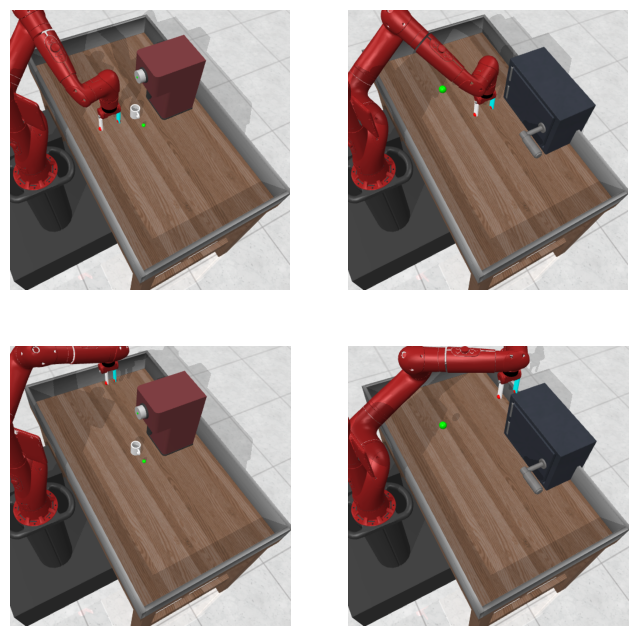

In [15]:
fig, ax = plt.subplots(2, len(envs_to_render), figsize=(4*len(envs_to_render), 8))


for env_idx, env_name in enumerate(envs_to_render):
    set_seed(int(actions[env_name]['seed']))
    env = gym.make('Meta-World/MT1', env_name=name_to_env[env_name], render_mode='rgb_array', camera_name='corner3')
    obs, _ = env.reset(seed=int(actions[env_name]['seed']))
    img = env.render()
    ax[0, env_idx].imshow(np.rot90(img, k=2))
    ax[0, env_idx].axis('off')

    for action in actions[env_name]['actions']:
        for _ in range(4):
            obs, reward, done, truncated, info = env.step(action)
        if truncated:
            print('forced to reset')
            obs, _ = env.reset(seed=int(actions[env_name]['seed']))
    img = env.render()
    ax[1, env_idx].imshow(np.rot90(img, k=2))
    # ax[1, env_idx].set_title(f'{env_name} - difference', fontsize=16)
    ax[1, env_idx].axis('off')

plt.axis('off')
plt.show()

In [16]:
fig.savefig('/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/coffee_dyn.png', bbox_inches=ax[1, 0].get_window_extent().transformed(fig.dpi_scale_trans.inverted()), dpi=300)

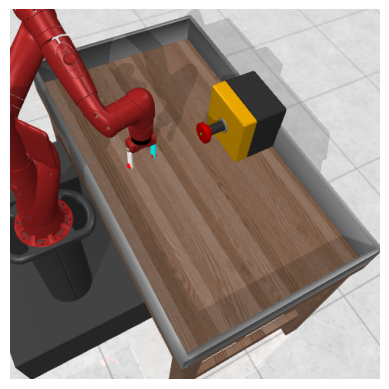

In [ ]:
env_name = 'button'
env = gym.make('Meta-World/MT1', env_name=name_to_env[env_name], render_mode='rgb_array', camera_name='corner3')
obs, _ = env.reset()
img = env.render()
plt.imshow(np.rot90(img, k=2))
plt.axis('off')
plt.savefig('/home/ayush/Desktop/tutorials/rl_latent/E2C/src/data_gen/temp_figs/' + env_name + '_start.png', bbox_inches='tight', dpi=300)
plt.show()

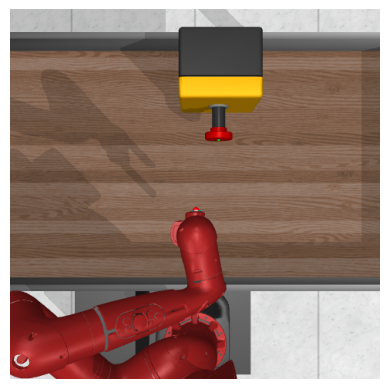

In [50]:
# fig, ax = plt.subplots(5, 1, figsize=(4, 20))
# for i, env_name in enumerate(['button', 'coffee', 'door', 'drawer', 'faucet']):
for i, env_name in enumerate(['button']):
    env = gym.make('Meta-World/MT1', env_name=name_to_env[env_name], render_mode='rgb_array', camera_name='topview')
    obs, _ = env.reset()
    img = env.render()
    plt.imshow(img)
    plt.axis('off')
    plt.savefig("temp_figs/" + env_name + "_topdown.png", bbox_inches='tight', dpi=200)
#     ax[i].imshow(img)
#     ax[i].set_title(f'{env_name} - topview', fontsize=16)
#     ax[i].axis('off')
# plt.axis('off')
# plt.show()